%%%%%%%%%%%%%%MALL CUSTOMER SEGMENTATION USING KMEANS%%%%%%%%%%%%%%%%%%%

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


In [2]:
# downloading the dataset into Pandas DataFrame
customer_data = pd.read_csv("Mall_Customers.csv")

In [3]:
customer_data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
customer_data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
customer_data.shape

(200, 5)

In [7]:
customer_data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
# Exploratory Data Analysis on Customer Segmentation

In [9]:
sns.set_style("darkgrid")

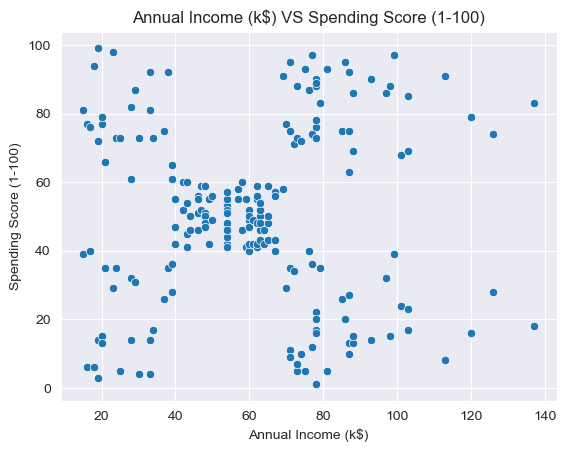

In [10]:
sns.scatterplot(data = customer_data , x = 'Annual Income (k$)', y = 'Spending Score (1-100)')
plt.title("Annual Income (k$) VS Spending Score (1-100)")
plt.show()

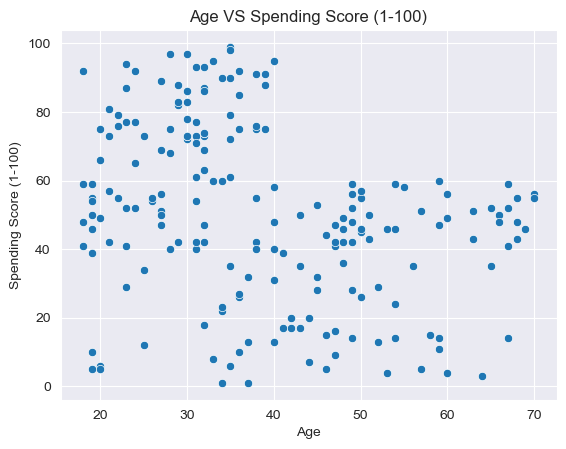

In [11]:
sns.scatterplot(data = customer_data , x = 'Age', y = 'Spending Score (1-100)')
plt.title("Age VS Spending Score (1-100)")
plt.show()

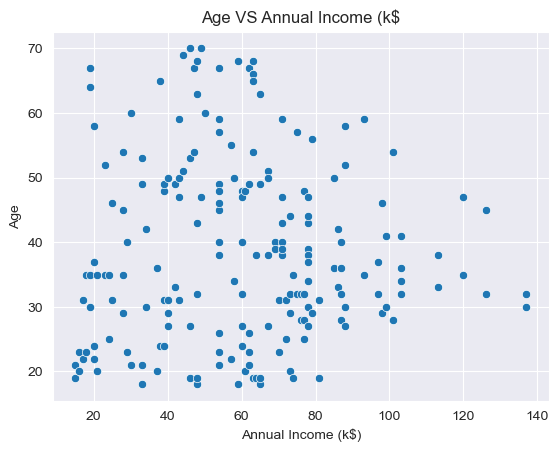

In [12]:
sns.scatterplot(data = customer_data , x = 'Annual Income (k$)', y = 'Age')
plt.title("Age VS Annual Income (k$")
plt.show()

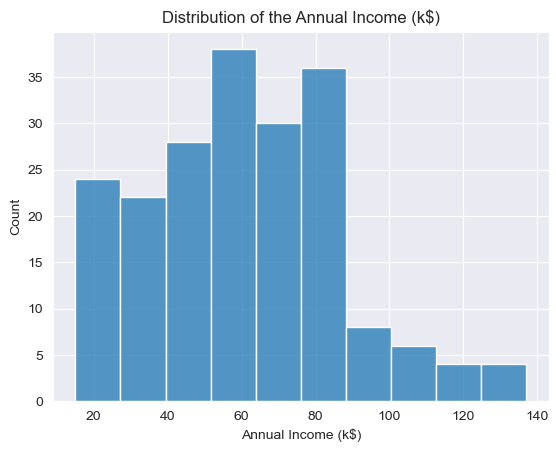

In [13]:
sns.histplot(data = customer_data , x = "Annual Income (k$)" )
plt.title("Distribution of the Annual Income (k$)")
plt.show()

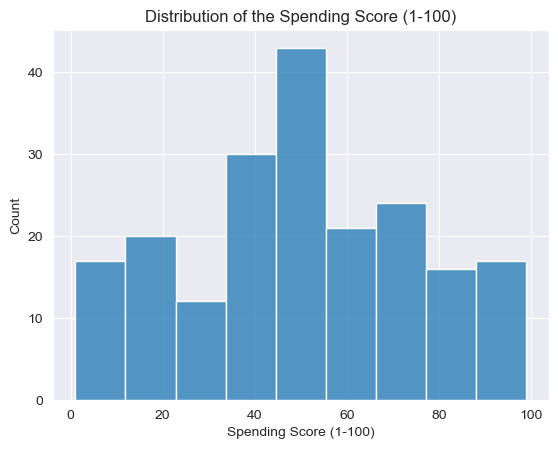

In [14]:
sns.histplot(data = customer_data , x = "Spending Score (1-100)")
plt.title("Distribution of the Spending Score (1-100)")
plt.show()

In [15]:
# Getting only  Annual Income (k$) AND Spending Score (1-100) to train the model

In [16]:
inputs = customer_data.iloc[:,[3,4]].values

In [17]:
inputs

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [18]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [19]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
# Plotting the graph to get the best cluster by training the model using different values as a cluster

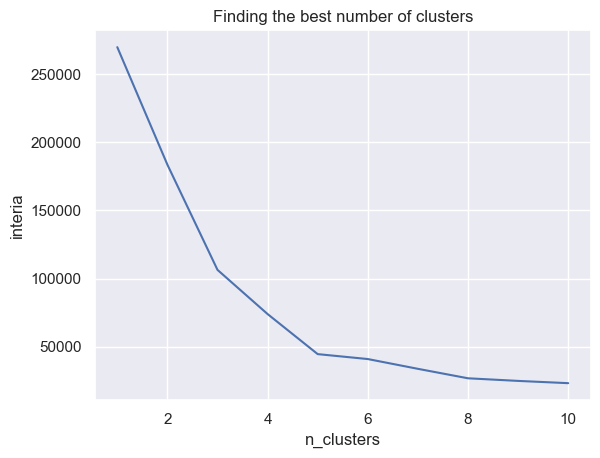

In [21]:
options = range(1,11)
inertias = []
for n in options:
    model = KMeans(n_clusters = n, random_state = 42)
    model.fit(inputs)
    inertias.append(model.inertia_)
sns.set()
plt.plot(options, inertias)
plt.title("Finding the best number of clusters")
plt.xlabel("n_clusters")
plt.ylabel("interia")
plt.show()

In [22]:
# It seems to be 5 as the optimal clusters to have becuase of significant drop in the 5

In [23]:
model = KMeans(n_clusters = 5 , random_state = 42)
model.fit(inputs)
preds = model.predict(inputs)
preds

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [24]:
model.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

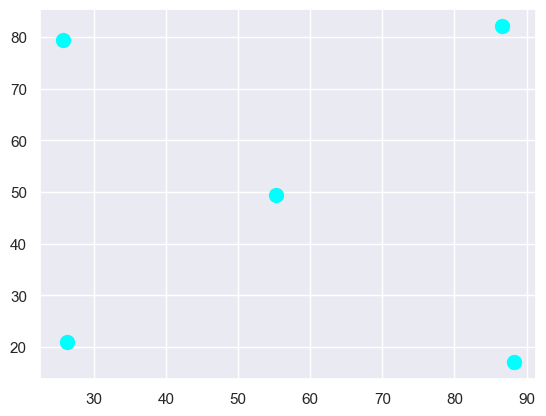

In [25]:
# Gettting the cendroids of the 5 clusters
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1] , s  =100 , c = "cyan" , label = "Cendroid")

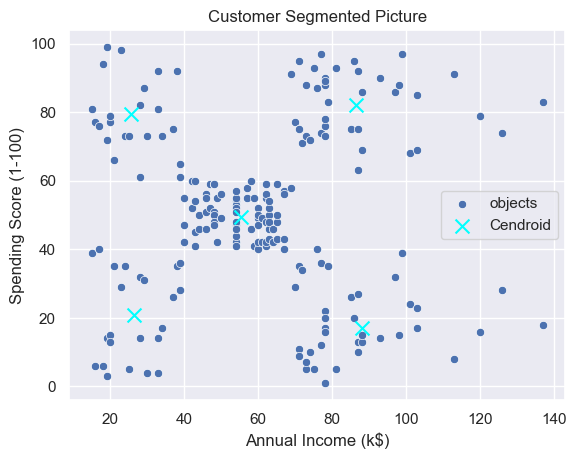

In [26]:
sns.scatterplot(data = customer_data , x= "Annual Income (k$)", y = "Spending Score (1-100)", label = "objects")
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1] , s  =100 , c = "cyan" ,marker = "x" ,label = "Cendroid")
plt.title("Customer Segmented Picture")
plt.legend()
plt.show()